In [1]:
import pandas as pd
import matplotlib.pyplot as plt

round_df = pd.read_csv("/content/afl_plyer_rbr_st_raw.csv")
team_df = pd.read_csv("/content/team_matches_home_away_raw.csv.csv")

print("Round-by-Round shape:", round_df.shape)
print("Team Match shape:", team_df.shape)

Round-by-Round shape: (274089, 36)
Team Match shape: (15808, 19)


**Team names clean**

In [2]:
round_df["team_key"] = (
    round_df["team"]
    .astype(str)
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

team_df["team_key"] = (
    team_df["team_name"]
    .astype(str)
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

**Team name mismatch fix**

In [3]:
team_df["team_key"] = team_df["team_key"].replace({
    "W. Bulldogs": "Western Bulldogs"
})

**Round clean**

In [4]:
round_df["round_key"] = (
    round_df["round"]
    .astype(str)
    .str.strip()
)

team_df["round_key"] = (
    team_df["round"]
    .astype(str)
    .str.strip()
)

**Match date standardize**

In [5]:
round_df["date_key"] = pd.to_datetime(
    round_df["match_date"],
    errors="coerce"
).dt.strftime("%Y-%m-%d")

team_df["date_key"] = pd.to_datetime(
    team_df["match_date"],
    errors="coerce"
).dt.strftime("%Y-%m-%d")

**Context dataset**

In [6]:
context_df = team_df[
    [
        "team_key",
        "year",
        "round_key",
        "date_key",
        "home_away",
        "venue",
        "crowd"
    ]
].copy()

print(context_df.shape)

(15808, 7)


**Composite key duplicate check**

In [7]:
duplicate_keys = context_df.duplicated(
    subset=[
        "team_key",
        "year",
        "round_key",
        "date_key"
    ]
).sum()

print("Duplicate composite keys:", duplicate_keys)

Duplicate composite keys: 0


**FINAL MERGE**

In [8]:
enriched_df = round_df.merge(
    context_df,
    on=[
        "team_key",
        "year",
        "round_key",
        "date_key"
    ],
    how="left"
)

print("Merge completed!")
print("Rows before merge:", len(round_df))
print("Rows after merge:", len(enriched_df))

Merge completed!
Rows before merge: 274089
Rows after merge: 274089


**Check enriched data**

In [9]:
enriched_df[
    [
        "team",
        "year",
        "round",
        "match_date",
        "home_away",
        "venue",
        "crowd",
        "fantasy_points"
    ]
].head(10)

,team,year,round,match_date,home_away,venue,crowd,fantasy_points
0,Hawthorn Hawks,1994,21,1994-08-14,A,Melbourne Cricket Ground,52562.0,36
1,Geelong Cats,2024,1,2024-03-16,H,GMHBA Stadium,39352.0,23
2,Essendon Bombers,1999,10,1999-06-04,A,AAMI Stadium,39389.0,67
3,Western Bulldogs,1994,21,1994-08-13,A,Waverley Park\r\n,14653.0,81
4,Richmond Tigers,1997,10,1997-05-31,H,Melbourne Cricket Ground,28879.0,32
5,St Kilda Saints,2002,2,2002-04-07,A,Domain Stadium,21138.0,0
6,Fremantle Dockers,2002,2,2002-04-07,H,Domain Stadium,21138.0,3
7,Brisbane Lions,2002,10,2002-06-01,A,AAMI Stadium,47279.0,20
8,Fremantle Dockers,1997,20,1997-08-16,A,Waverley Park,26201.0,36
9,Port Adelaide Power,1997,20,1997-08-16,A,The Gabba,20835.0,68


**TASK 3 MERGE VALIDATION**

Unmatched records

In [10]:
validation_df = round_df.merge(
    context_df,
    on=[
        "team_key",
        "year",
        "round_key",
        "date_key"
    ],
    how="left",
    indicator=True
)

print(validation_df["_merge"].value_counts())

_merge
both          274089
left_only          0
right_only         0
Name: count, dtype: int64


Specifically unmatched records

In [11]:
unmatched = validation_df[
    validation_df["_merge"] == "left_only"
]

print("Unmatched records:", len(unmatched))

Unmatched records: 0


**Rows before/after**

In [12]:
print("Rows before merge:", len(round_df))
print("Rows after merge:", len(enriched_df))

if len(round_df) == len(enriched_df):
    print("PASS: Number of player records remained unchanged.")
else:
    print("WARNING: Number of records changed.")

Rows before merge: 274089
Rows after merge: 274089
PASS: Number of player records remained unchanged.


**Duplicates record**

In [13]:
duplicates_before = round_df.duplicated().sum()
duplicates_after = enriched_df.duplicated().sum()

print("Duplicates before merge:", duplicates_before)
print("Duplicates after merge:", duplicates_after)

Duplicates before merge: 10
Duplicates after merge: 10


**Check added columns**

In [14]:
print("Missing values in added columns:")

print(
    enriched_df[
        ["home_away", "venue", "crowd"]
    ].isna().sum()
)

Missing values in added columns:
home_away       0
venue           0
crowd        8955
dtype: int64


**TASK 4 CONTEXTUAL ANALYSIS**

Question 1: Home vs Away

In [15]:
home_away_analysis = (
    enriched_df
    .groupby("home_away")["fantasy_points"]
    .agg(["count", "mean", "median"])
)

print(home_away_analysis)

            count       mean  median
home_away                           
A          137016  64.003386    63.0
H          137073  66.484472    65.0


## Home vs Away Performance

Players recorded an average of 66.48 fantasy points in home matches and 64.00 fantasy points in away matches.

The difference between home and away average fantasy points is 2.48 points.

**Home/Away graph**

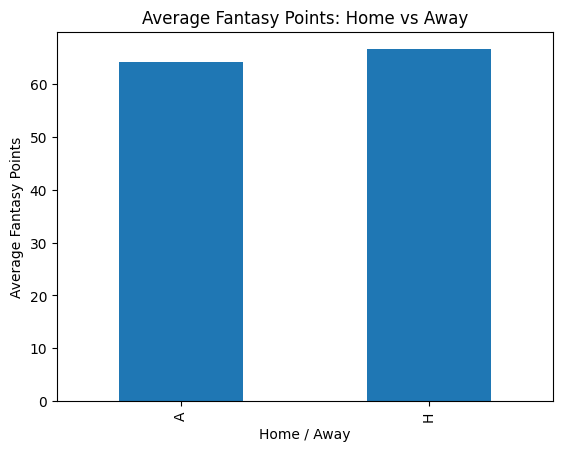

In [16]:
home_away_analysis["mean"].plot(
    kind="bar",
    title="Average Fantasy Points: Home vs Away",
    xlabel="Home / Away",
    ylabel="Average Fantasy Points"
)

plt.show()

Question 2 — Crowd vs Fantasy Points

In [17]:
crowd_correlation = (
    enriched_df[
        ["crowd", "fantasy_points"]
    ]
    .corr()
    .loc["crowd", "fantasy_points"]
)

print("Correlation:", crowd_correlation)

Correlation: 0.01289459378298295


## Crowd Size and Fantasy Points

The correlation between crowd size and fantasy points is approximately 0.013.

Because this value is very close to zero, crowd size shows a very weak linear relationship with fantasy points in this dataset.

**Crowd groups**

In [18]:
crowd_df = enriched_df.dropna(
    subset=["crowd"]
).copy()

crowd_df["crowd_group"] = pd.qcut(
    crowd_df["crowd"],
    q=3,
    labels=[
        "Low Crowd",
        "Medium Crowd",
        "High Crowd"
    ]
)

print(crowd_df["crowd_group"].value_counts())

crowd_group
Low Crowd       88422
Medium Crowd    88371
High Crowd      88341
Name: count, dtype: int64


**Crowd performance**

In [19]:
crowd_analysis = (
    crowd_df
    .groupby(
        "crowd_group",
        observed=True
    )["fantasy_points"]
    .agg(["count", "mean"])
)

print(crowd_analysis)

              count       mean
crowd_group                   
Low Crowd     88422  64.991778
Medium Crowd  88371  65.484763
High Crowd    88341  65.985216


**Crowd graph**

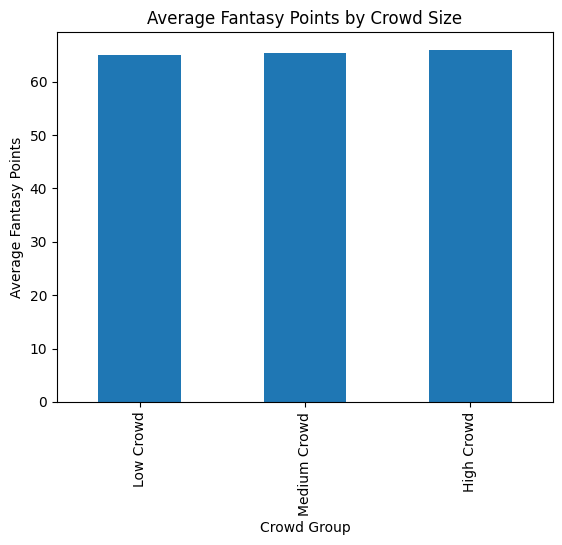

In [20]:
crowd_analysis["mean"].plot(
    kind="bar",
    title="Average Fantasy Points by Crowd Size",
    xlabel="Crowd Group",
    ylabel="Average Fantasy Points"
)

plt.show()

**Question 3 Venue Performance**

In [21]:
venue_analysis = (
    enriched_df
    .groupby("venue")["fantasy_points"]
    .agg(["count", "mean"])
    .sort_values(
        "mean",
        ascending=False
    )
)

print(venue_analysis.head(10))

                   count       mean
venue                              
Junction Oval          3  75.333333
TIO Stadium\r\n      112  74.187500
Jiangwan Stadium     137  72.481752
UTAS Stadium\r\n     133  70.879699
Riverway Stadium      46  70.369565
Westpac Stadium      134  69.716418
TIO Traeger Park     494  69.615385
Accor Stadium\r\n     45  68.866667
Mars Stadium         639  68.040689
UTAS Stadium        4185  67.962007


**Reliable venue comparison**

In [22]:
venue_100 = venue_analysis[
    venue_analysis["count"] >= 100
]

print(venue_100.head(10))

                  count       mean
venue                             
TIO Stadium\r\n     112  74.187500
Jiangwan Stadium    137  72.481752
UTAS Stadium\r\n    133  70.879699
Westpac Stadium     134  69.716418
TIO Traeger Park    494  69.615385
Mars Stadium        639  68.040689
UTAS Stadium       4185  67.962007
ENGIE Stadium      5010  67.852096
Marvel Stadium    50156  67.572354
Adelaide Oval     12836  67.563182


**Venue graph**

) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


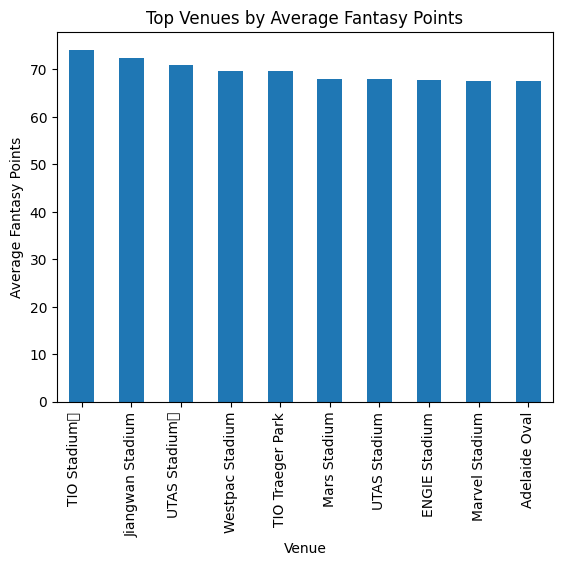

In [23]:
venue_100.head(10)["mean"].plot(
    kind="bar",
    title="Top Venues by Average Fantasy Points",
    xlabel="Venue",
    ylabel="Average Fantasy Points"
)

plt.show()

# Week 2 Day 5 — Data Quality Report

## Merge Keys

The datasets were merged using a composite key consisting of team, year, round, and match_date.

## Why Composite Key Was Used

A single team name was not sufficient because each team appears in many matches.

The combination of team, year, round, and match date was used to identify the correct match.

## Data Cleaning

Team names were cleaned by removing extra spaces.

"W. Bulldogs" was changed to "Western Bulldogs" so that the team names matched.

Round and match dates were also standardized before merging.

## Context Enrichment

The following columns were added to the Round-by-Round dataset:

- home_away
- venue
- crowd

## Merge Validation

There were 274,089 player records before the merge and 274,089 after the merge.

All 274,089 records were successfully matched.

There were 0 unmatched records.

## Duplicate Check

There were 10 duplicate records before the merge and 10 duplicate records after the merge.

Therefore, the merge did not introduce any new duplicate records.

## Data Quality Issues

There were no missing values in home_away or venue.

There were 8,955 missing values in crowd.

The missing crowd values are treated as an existing data quality issue.

## Contextual Analysis

Home matches had an average of 66.48 fantasy points, while away matches had an average of 64.00 fantasy points.

The correlation between crowd size and fantasy points was approximately 0.013, showing a very weak linear relationship.

Junction Oval had the highest raw venue average of 75.33, but only 3 records were available.

Among venues with at least 100 records, TIO Stadium had the highest average fantasy points at approximately 74.19.

## Assumptions

It was assumed that team, year, round, and match date together identify the correct match.

Match context was applied to all player records belonging to the corresponding match.

## Conclusion

The Round-by-Round player dataset was successfully enriched with match context.

The enriched dataset can be used to analyze player performance based on home/away status, crowd attendance, and venue.